<a href="https://colab.research.google.com/github/ElzaJung/MediMapAI/blob/main/Tumor_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

base_dir = "/content/drive/My Drive/MediMapAI/tumor_classification"
os.makedirs(base_dir, exist_ok=True)

print(f"Base directory for saving files: {base_dir}")

Mounted at /content/drive
Base directory for saving files: /content/drive/My Drive/MediMapAI/tumor_classification


In [ ]:
# Using brain-tumor-mri-dataset from Kaggle
!pip install kaggle
!mkdir ~/.kaggle
!echo '{"username":"elzaelzae","key":"bd814170e7f228009323a963701d7112"}' > ~/.kaggle/kaggle.json
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip brain-tumor-mri-dataset.zip -d brain-tumor-mri-dataset/

Streaming output truncated to the last 5000 lines.
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0712.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0713.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0714.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0715.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0716.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0717.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0718.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0719.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0720.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0721.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0722.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0723.jpg  
  inflating: brain-tumor-mri-dataset/Training/glioma/Tr-gl_0724.jpg  
  inflating: brain-tumor-mri-dataset/Tr

In [ ]:
import os
import random
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
from IPython.display import Image
import imutils

In [ ]:
os.mkdir("/content/Crop-Brain-MRI/")
os.mkdir("/content/Crop-Brain-MRI/glioma")
os.mkdir("/content/Crop-Brain-MRI/meningioma")
os.mkdir("/content/Crop-Brain-MRI/notumor")
os.mkdir("/content/Crop-Brain-MRI/pituitary")

In [ ]:
os.mkdir("/content/Test-Data")
os.mkdir("/content/Test-Data/glioma")
os.mkdir("/content/Test-Data/meningioma")
os.mkdir("/content/Test-Data/notumor")
os.mkdir("/content/Test-Data/pituitary")

# Data Visualization

In [ ]:
train_dir = "/content/brain-tumor-mri-dataset/Training"
test_dir = "/content/brain-tumor-mri-dataset/Testing"

In [ ]:
classes = os.listdir("/content/brain-tumor-mri-dataset/Training")

In [ ]:
classes

['notumor', 'glioma', 'meningioma', 'pituitary']

In [ ]:
filepath_dict = {}
for c in classes:
  filepath_dict[c] = list(map(lambda x: train_dir + "/" + c + "/" + x, os.listdir(train_dir + "/" + c)))

In [ ]:
filepath_dict

{'notumor': ['/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_1337.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_0330.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_0912.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_1567.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_1493.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_0196.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_1548.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_0661.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_1545.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_0956.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_0472.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_0020.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_0233.jpg',
  '/content/brain-tumor-mri-dataset/Training/notumor/Tr-no_1056.jpg',
  '/conte

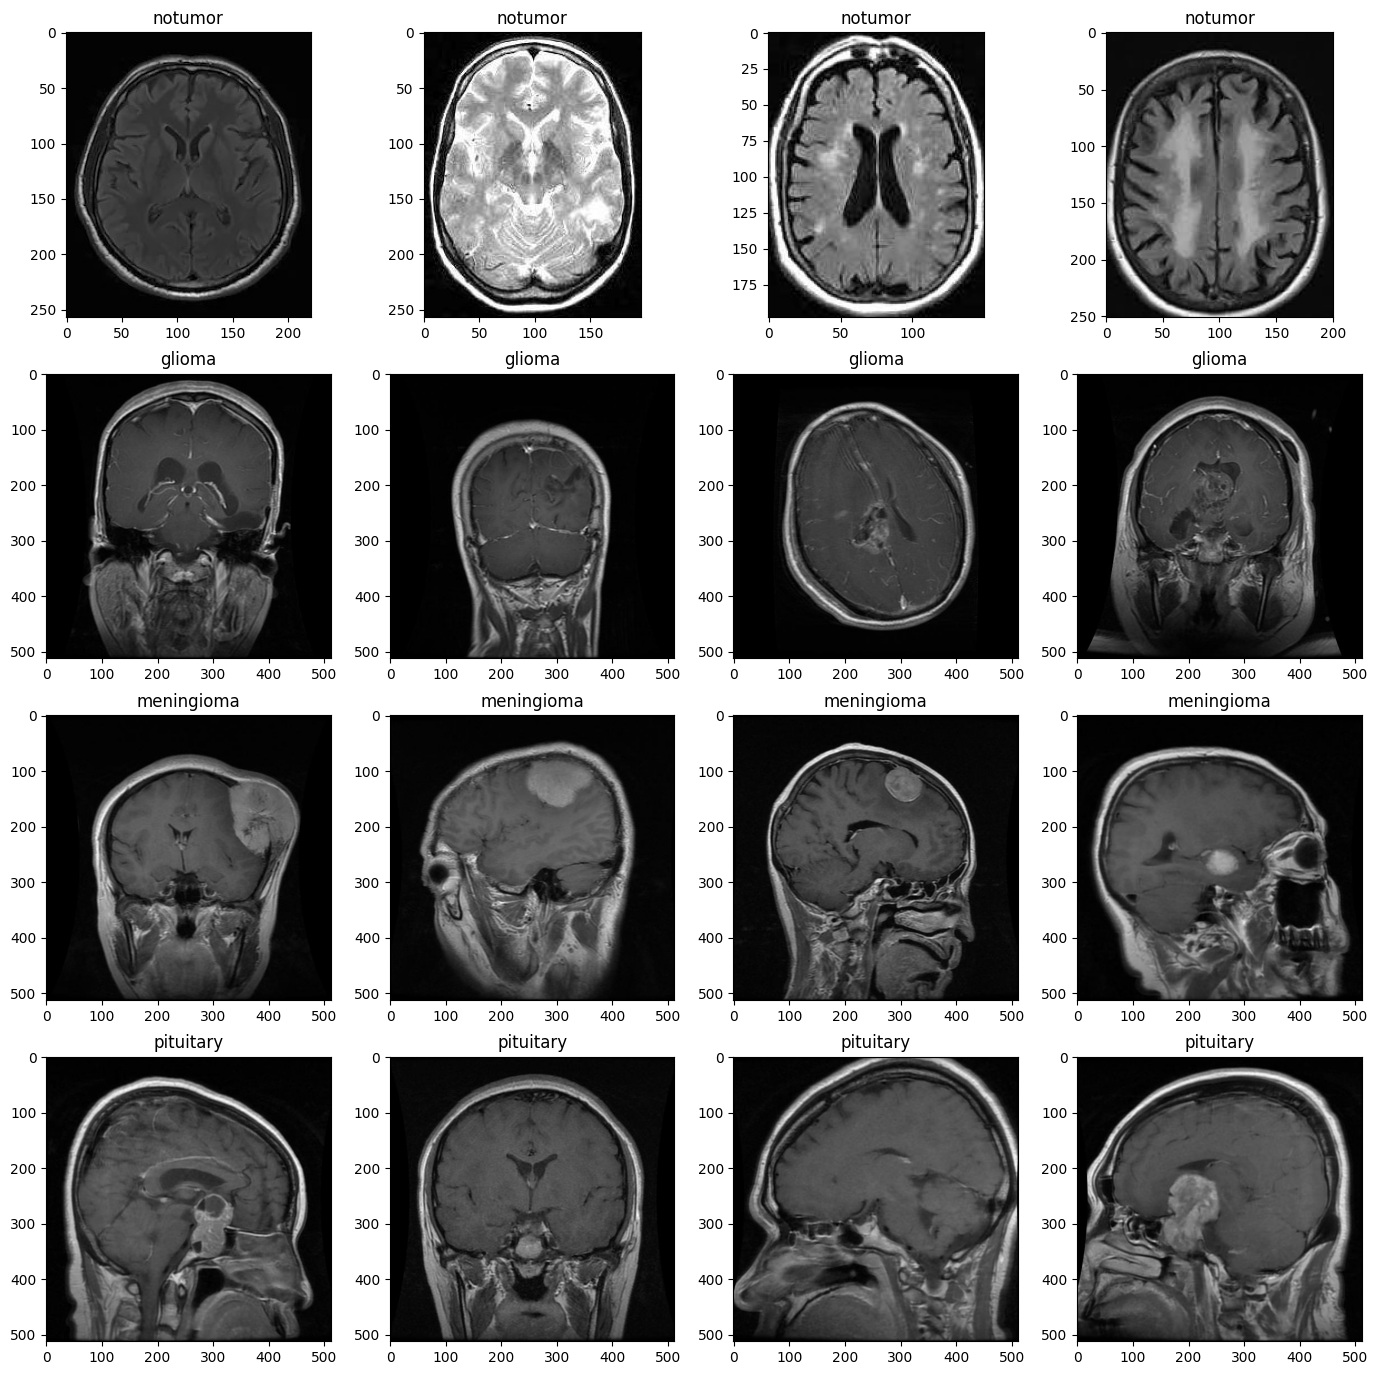

In [ ]:
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize = (17, 17))

index = 0
for c in classes:
  random.shuffle(filepath_dict[c])
  path_list = filepath_dict[c][:5]

  for i in range(1, 5):
    index +=1
    plt.subplot(4, 4, index)
    plt.imshow(load_img(path_list[i]))
    plt.title(c)

# Data Selection

In [ ]:
No_images_per_class =[]
Class_name = []
for i in os.listdir("/content/brain-tumor-mri-dataset/Training"):
  train_class = os.listdir(os.path.join("/content/brain-tumor-mri-dataset/Training", i))
  No_images_per_class.append(len(train_class))
  Class_name.append(i)
  print(f"Number of images in {i} : {len(train_class)}")

Number of images in notumor : 1595
Number of images in glioma : 1321
Number of images in meningioma : 1339
Number of images in pituitary : 1457


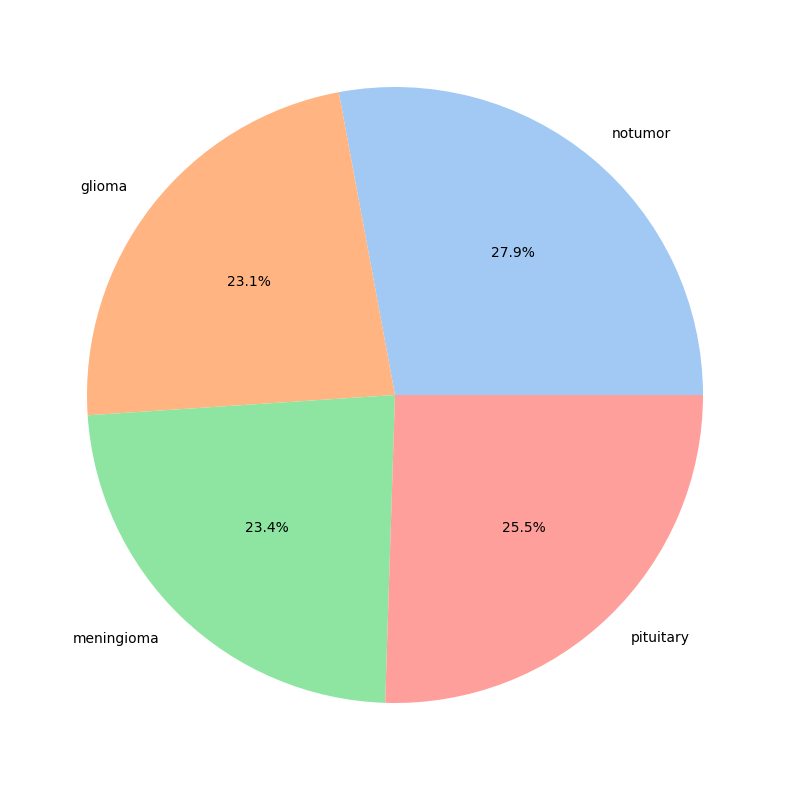

In [ ]:
plt.figure(figsize = (10, 10))
colors = sns.color_palette('pastel')
plt.pie(No_images_per_class, labels = Class_name, autopct = "%1.1f%%", colors = colors)
plt.show()

# Data prepocessing using cv2
- removing background
  - GaussianBlur
  - contouring

In [ ]:
def crop_image(image, plot = False):
  img_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
  img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
  img_thresh = cv2.threshold(img_blur, 45, 255, cv2.THRESH_BINARY)[1]
  img_thresh = cv2.erode(img_thresh, None, iterations =2)
  img_thresh = cv2.dilate(img_thresh, None, iterations =2)

  contours = cv2.findContours(img_thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

  contours = imutils.grab_contours(contours)

  c = max(contours, key = cv2.contourArea)

  # Get bounding rectangle coordinates
  x, y, w, h = cv2.boundingRect(c)

  # Crop the image using the bounding rectangle
  new_img = image[y:y + h, x:x + w]

  if plot:
    plt.figure(figsize= (15,6))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.subplot(1,2,2)
    plt.imshow(new_img)
    plt.title("Cropped Image")
    plt.show()
  return new_img

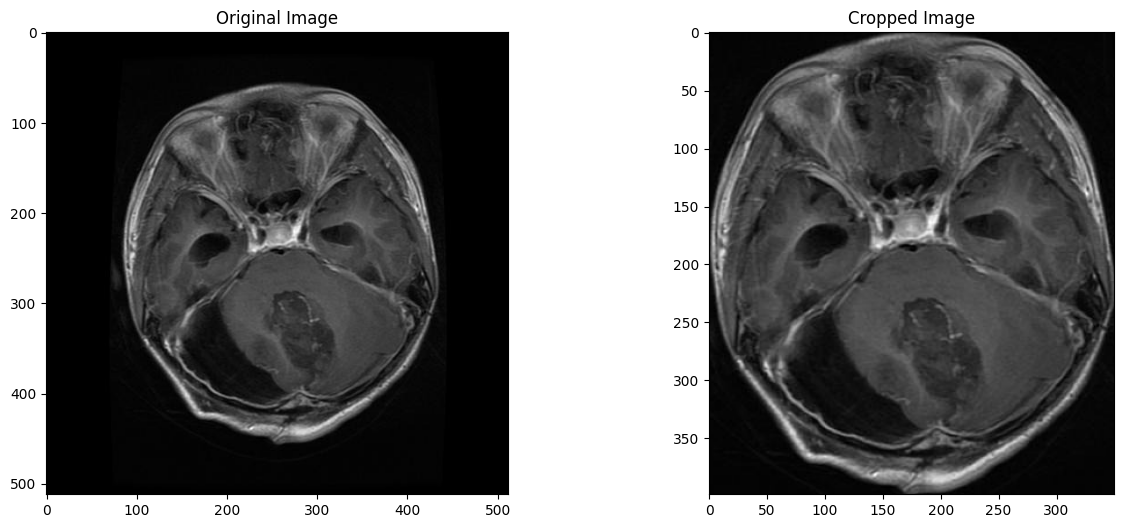

In [ ]:
example_img = cv2.imread("/content/brain-tumor-mri-dataset/Testing/glioma/Te-glTr_0000.jpg")
cropped_imgs = crop_image(example_img, plot =True)

# Saving the cropped Images

In [ ]:
glioma = train_dir + '/glioma'
meningioma = train_dir + '/meningioma'
notumor = train_dir + '/notumor'
pituitary = train_dir + '/pituitary'

j=0
for i in tqdm(os.listdir(glioma)):
  path = os.path.join(glioma, i)
  img = cv2.imread(path)
  img = crop_image(img)
  if img is not None:
    cv2.resize(img, (240, 240))
    save_path = "/content/Crop-Brain-MRI/glioma/" + str(j) +'.jpg'
    cv2.imwrite(save_path, img)
    j = j+1

100%|██████████| 1321/1321 [00:09<00:00, 136.43it/s]


In [ ]:
j=0
for i in tqdm(os.listdir(meningioma)):
  path = os.path.join(meningioma, i)
  img = cv2.imread(path)
  img = crop_image(img)
  if img is not None:
    cv2.resize(img, (240, 240))
    save_path = "/content/Crop-Brain-MRI/meningioma/" + str(j) +'.jpg'
    cv2.imwrite(save_path, img)
    j = j+1

j=0
for i in tqdm(os.listdir(notumor)):
  path = os.path.join(notumor, i)
  img = cv2.imread(path)
  img = crop_image(img)
  if img is not None:
    cv2.resize(img, (240, 240))
    save_path = "/content/Crop-Brain-MRI/notumor/" + str(j) +'.jpg'
    cv2.imwrite(save_path, img)
    j = j+1

j=0
for i in tqdm(os.listdir(pituitary)):
  path = os.path.join(pituitary, i)
  img = cv2.imread(path)
  img = crop_image(img)
  if img is not None:
    cv2.resize(img, (240, 240))
    save_path = "/content/Crop-Brain-MRI/pituitary/" + str(j) +'.jpg'
    cv2.imwrite(save_path, img)
    j = j+1

100%|██████████| 1457/1457 [00:06<00:00, 211.26it/s]


In [ ]:
test_glioma = test_dir + '/glioma'
test_meningioma = test_dir + '/meningioma'
test_notumor = test_dir + '/notumor'
test_pituitary = test_dir + '/pituitary'

j=0
for i in tqdm(os.listdir(test_glioma)):
  path = os.path.join(test_glioma, i)
  img = cv2.imread(path)
  img = crop_image(img)
  if img is not None:
    cv2.resize(img, (240, 240))
    save_path = "/content/Test-Data/glioma/" + str(j) +'.jpg'
    cv2.imwrite(save_path, img)
    j = j+1

j=0
for i in tqdm(os.listdir(test_meningioma)):
  path = os.path.join(test_meningioma, i)
  img = cv2.imread(path)
  img = crop_image(img)
  if img is not None:
    cv2.resize(img, (240, 240))
    save_path = "/content/Test-Data/meningioma/" + str(j) +'.jpg'
    cv2.imwrite(save_path, img)
    j = j+1

j=0
for i in tqdm(os.listdir(test_notumor)):
  path = os.path.join(test_notumor, i)
  img = cv2.imread(path)
  img = crop_image(img)
  if img is not None:
    cv2.resize(img, (240, 240))
    save_path = "/content/Test-Data/notumor/" + str(j) +'.jpg'
    cv2.imwrite(save_path, img)
    j = j+1

j=0
for i in tqdm(os.listdir(test_pituitary)):
  path = os.path.join(test_pituitary, i)
  img = cv2.imread(path)
  img = crop_image(img)
  if img is not None:
    cv2.resize(img, (240, 240))
    save_path = "/content/Test-Data/pituitary/" + str(j) +'.jpg'
    cv2.imwrite(save_path, img)
    j = j+1

100%|██████████| 300/300 [00:01<00:00, 261.93it/s]


#Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array

In [ ]:
datagen = ImageDataGenerator(
    rotation_range = 10,
    height_shift_range = 0.2,
    horizontal_flip = True,
    validation_split = 0.2
)

train_data = datagen.flow_from_directory('/content/Crop-Brain-MRI', target_size=(240, 240), batch_size=32, class_mode='categorical', subset='training')

valid_data = datagen.flow_from_directory('/content/Crop-Brain-MRI', target_size=(240, 240), batch_size=32, class_mode='categorical', subset='validation')

test_datagen = ImageDataGenerator()
test_data = datagen.flow_from_directory('/content/Test-Data', target_size=(240, 240), batch_size=32, class_mode='categorical', shuffle = False)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


In [ ]:
test_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

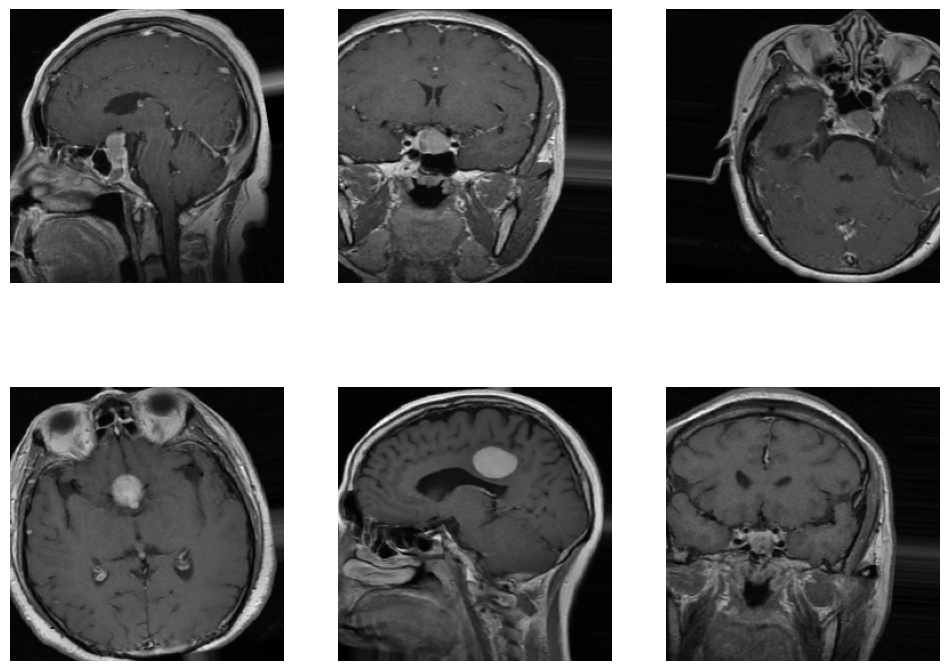

In [ ]:
sample_x, sample_y = next(train_data)

plt.figure(figsize = (12, 9))

for i in range(6):
  plt.subplot(2, 3, i+1)
  sample = array_to_img(sample_x[i])
  plt.axis('off')
  plt.grid(False)
  plt.imshow(sample)

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB1
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Conv2D, Dropout, GlobalMaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
effnet = EfficientNetB1(weights = 'imagenet', include_top = False, input_shape= (240, 240, 3))

model = effnet.output
model = GlobalMaxPooling2D()(model)
model = Dropout(0.5)(model)
model = Dense(4, activation="softmax")(model)
model = Model(inputs = effnet.input, outputs = model)
model.summary()

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 240, 240, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 240, 240, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 240, 240, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 240, 240, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 241, 241, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 120, 120, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 120, 120, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 120, 120, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 120, 120, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 120, 120, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 120, 120, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_expand    

 Total params: 6,580,363 (25.10 MB)

 Trainable params: 6,518,308 (24.87 MB)

 Non-trainable params: 62,055 (242.41 KB)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', save_best_only=True, mode = 'auto', verbose=1)
earlystop=EarlyStopping(monitor = 'val_accuracy', patience=5, mode='auto', verbose=1)
reduced_lr = ReduceLROnPlateau(monitor = 'val_accuracy', factor=0.3, patience=2, min_dealta=0.001, mode='auto', verbose=1)

In [ ]:
%%time
history = model.fit(train_data, epochs = 30, validation_data = valid_data, verbose=1, callbacks = [checkpoint, earlystop, reduced_lr])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 882ms/step - accuracy: 0.5051 - loss: 3.6757
Epoch 1: val_accuracy improved from -inf to 0.82033, saving model to model.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.5060 - loss: 3.6666 - val_accuracy: 0.8203 - val_loss: 0.6972 - learning_rate: 1.0000e-04
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.8195 - loss: 0.9046
Epoch 2: val_accuracy improved from 0.82033 to 0.82384, saving model to model.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 89s 626ms/step - accuracy: 0.8195 - loss: 0.9041 - val_accuracy: 0.8238 - val_loss: 0.7402 - learning_rate: 1.0000e-04
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.8946 - loss: 0.4561
Epoch 3: val_accuracy improved from 0.82384 to 0.85977, saving model to model.keras
143/143 ━━━━━━━━━━━━━━━━━━━━ 150s 683ms/step - accuracy: 0.8946 - loss: 0.4561 - val_accuracy: 0.8598 - val_loss: 0.5622 - learning_rate: 1.0000e-04
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 5

# Data Visualization
1. Line Graphs for tracking accuracy & loss improvement along with growth of Epochs
2. Confusion Matrix to compare predicted values to actual values
3. Classification Report
4. Shuffle Testing

Text(0, 0.5, 'loss')

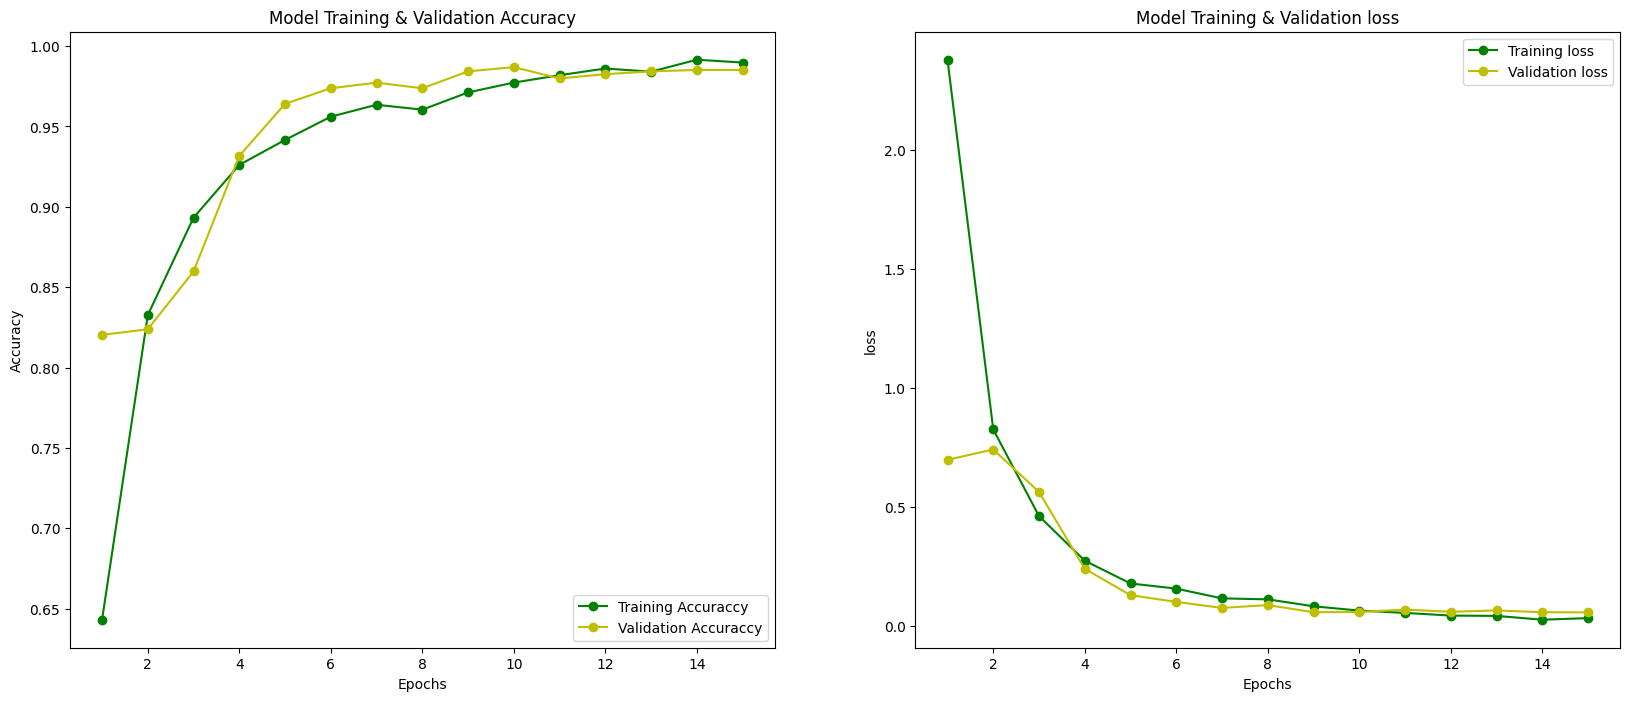

In [ ]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(20, 8)

train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epoches = range (1, len(train_acc)+1)

ax[0].plot(epoches, train_acc, 'g-o', label = 'Training Accuraccy')
ax[0].plot(epoches, val_acc, 'y-o', label = 'Validation Accuraccy')
ax[0].set_title('Model Training & Validation Accuracy')
ax[0].legend(loc = 'lower right')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')

ax[1].plot(epoches, train_loss, 'g-o', label = 'Training loss')
ax[1].plot(epoches, val_loss, 'y-o', label = 'Validation loss')
ax[1].set_title('Model Training & Validation loss')
ax[1].legend()
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('loss')

In [ ]:
model.evaluate(train_data)

143/143 ━━━━━━━━━━━━━━━━━━━━ 66s 464ms/step - accuracy: 0.9992 - loss: 0.0043


[0.00523093156516552, 0.9986873865127563]

In [ ]:
model.evaluate(test_data)

41/41 ━━━━━━━━━━━━━━━━━━━━ 25s 617ms/step - accuracy: 0.9771 - loss: 0.0612


[0.048117175698280334, 0.986270010471344]

In [ ]:
y_test = test_data.classes
y_test_hat = np.argmax(model.predict(test_data), axis=1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 33s 626ms/step


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, accuracy_score, confusion_matrix, classification_report

In [ ]:
cm = confusion_matrix(y_test, y_test_hat)
cm

array([[293,   6,   0,   1],
       [  1, 304,   0,   1],
       [  1,   0, 404,   0],
       [  0,   1,   0, 299]])

In [ ]:
test_data.class_indices

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

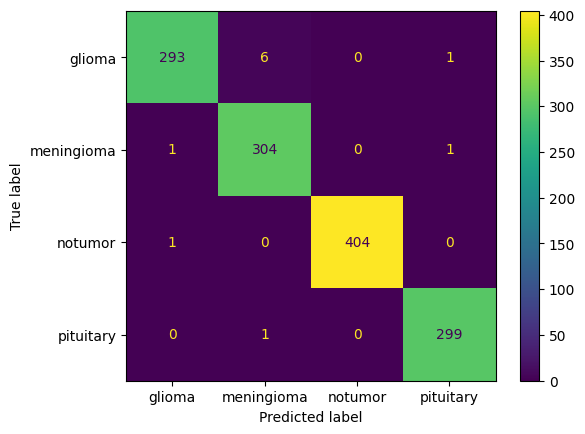

In [ ]:
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['glioma', 'meningioma', 'notumor', 'pituitary'])
cm_display.plot()
plt.show()

In [ ]:
print(classification_report(y_test, y_test_hat))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       300
           1       0.98      0.99      0.99       306
           2       1.00      1.00      1.00       405
           3       0.99      1.00      1.00       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



In [ ]:
CLASS_DICT = {0: 'glioma', 1: 'meningioma', 2: 'notumor', 3: 'pituitary'}

images = []
predictions = []
original =[]
for i in os.listdir('/content/Test-Data'):
  for item in os.listdir(os.path.join('/content/Test-Data/',i)):
    img_path = os.path.join('/content/Test-Data', i, item)
    img = load_img(img_path, target_size=(240, 240))
    img = img_to_array(img)
    img = np.expand_dims(img, axis = 0)
    images.append(img)

    predict = model.predict(img)
    predict = np.argmax(predict)
    predictions.append(predict)
    original.append(i)

print(len(images), len(predictions), len(original))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━

In [ ]:
predictions = [CLASS_DICT[x] for x in predictions]

print(original[1], predictions[1])

notumor notumor


In [ ]:
score = accuracy_score(original, predictions)
score

0.9816933638443935

1311


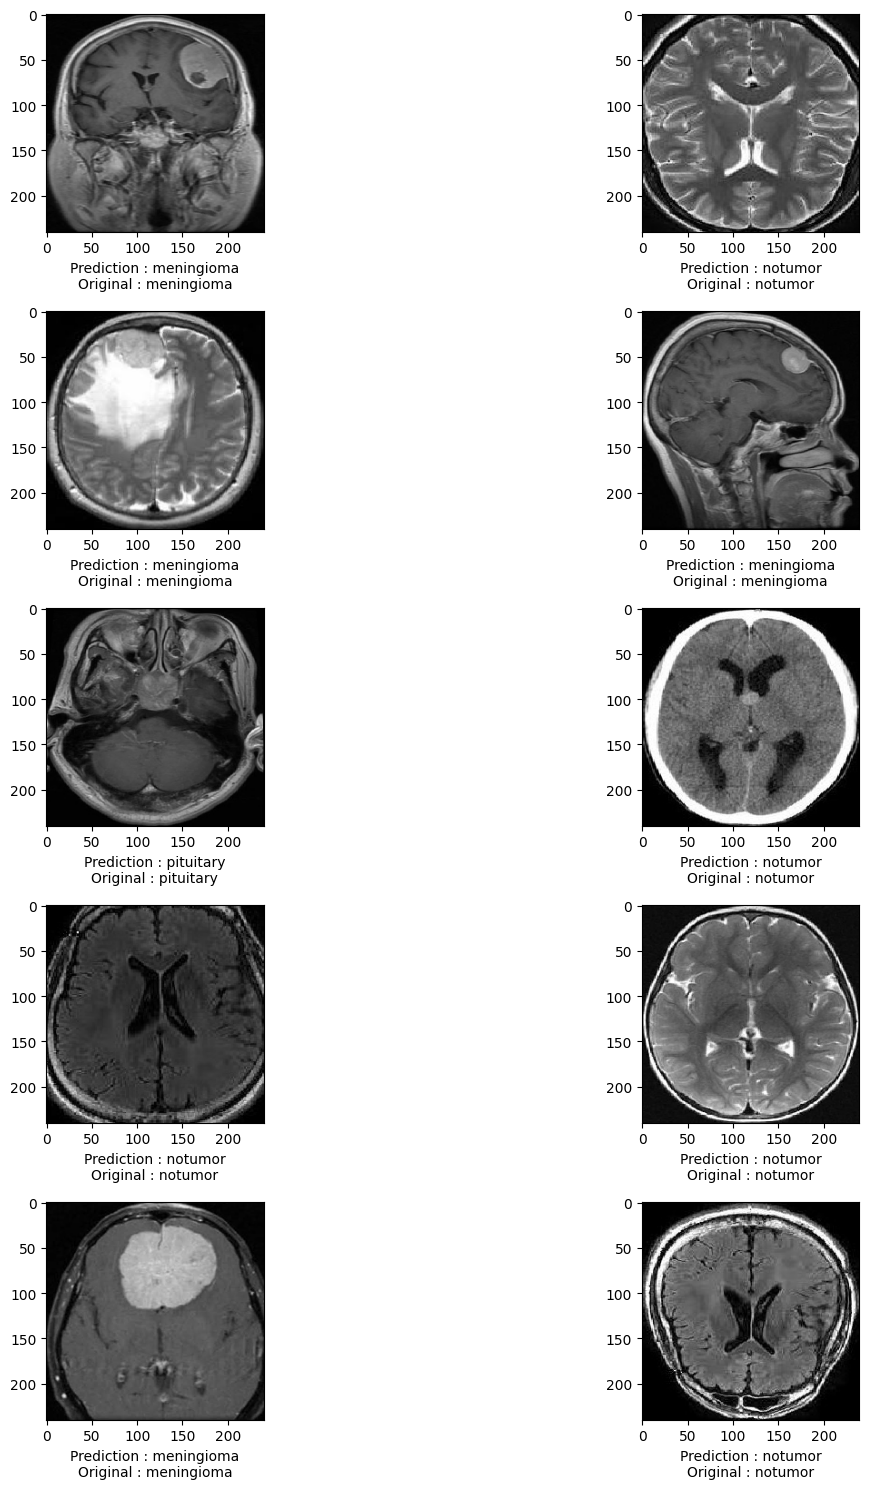

In [ ]:
fig = plt.figure(figsize=(15, 15))

print(len(images))

for i in range(10):
  j = random.randint(0, len(images))
  fig.add_subplot(5, 2, i+1)
  plt.xlabel("Prediction : " + predictions[j] + "\n" + "Original : " + original[j])
  plt.imshow(np.squeeze(images[j]).astype("uint8"))  # Remove batch dimension & convert to valid type
fig.tight_layout()
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/tumor_classification_model.h5')

In [ ]:
import tensorflow as tf
last_conv_layer = next(x for x in model.layers[::-1] if isinstance(x, tf.keras.layers.Conv2D))
last_conv_layer.name

'top_conv'

In [ ]:
import cv2
import numpy as np
from PIL import Image
import tensorflow as tf
import tensorflow.keras as K
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras.models import Model


def VizGradCAM(model, image, interpolant=0.5, plot_results=True):
    """VizGradCAM - Displays GradCAM based on Keras / TensorFlow models
    using the gradients from the last convolutional layer. This function
    should work with all Keras Application listed here:
    https://keras.io/api/applications/

    Parameters:
    model (keras.model): Compiled Model with Weights Loaded
    image: Image to Perform Inference On
    plot_results (boolean): True - Function Plots using PLT
                            False - Returns Heatmap Array

    Returns:
    Heatmap Array?
    """
    # Sanity Check
    assert (
        interpolant > 0 and interpolant < 1
    ), "Heatmap Interpolation Must Be Between 0 - 1"

    last_conv_layer = next(
        x for x in model.layers[::-1] if isinstance(x, K.layers.Conv2D)
    )
    target_layer = model.get_layer(last_conv_layer.name)

    original_img = image
    img = np.expand_dims(original_img, axis=0)
    prediction = model.predict(img)

    # Obtain Prediction Index
    prediction_idx = np.argmax(prediction)

    # Compute Gradient of Top Predicted Class
    with tf.GradientTape() as tape:
        gradient_model = Model([model.inputs], [target_layer.output, model.output])
        conv2d_out, prediction = gradient_model(img)
        # Obtain the Prediction Loss
        loss = prediction[:, prediction_idx]

    # Gradient() computes the gradient using operations recorded
    # in context of this tape
    gradients = tape.gradient(loss, conv2d_out)

    # Obtain the Output from Shape [1 x H x W x CHANNEL] -> [H x W x CHANNEL]
    output = conv2d_out[0]

    # Obtain Depthwise Mean
    weights = tf.reduce_mean(gradients[0], axis=(0, 1))

    # Create a 7x7 Map for Aggregation
    activation_map = np.zeros(output.shape[0:2], dtype=np.float32)

    # Multiply Weights with Every Layer
    for idx, weight in enumerate(weights):
        activation_map += weight * output[:, :, idx]

    # Resize to Size of Image
    activation_map = cv2.resize(
        activation_map.numpy(), (original_img.shape[1], original_img.shape[0])
    )

    # Ensure No Negative Numbers
    activation_map = np.maximum(activation_map, 0)

    # Convert Class Activation Map to 0 - 255
    activation_map = (activation_map - activation_map.min()) / (
        activation_map.max() - activation_map.min()
    )
    activation_map = np.uint8(255 * activation_map)

    # Convert to Heatmap
    heatmap = cv2.applyColorMap(activation_map, cv2.COLORMAP_JET)

    # Superimpose Heatmap on Image Data
    original_img = np.uint8(
        (original_img - original_img.min())
        / (original_img.max() - original_img.min())
        * 255
    )

    cvt_heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Enlarge Plot
    plt.rcParams["figure.dpi"] = 100

    if plot_results == True:
        plt.imshow(
            np.uint8(original_img * interpolant + cvt_heatmap * (1 - interpolant))
        )
    else:
        return cvt_heatmap

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 240, 240, 3))
  warnings.warn(msg)


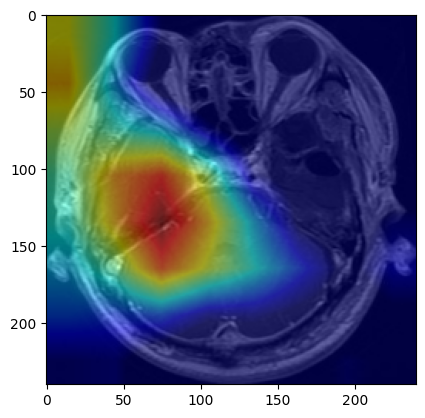

In [ ]:
test_img = cv2.imread("/content/Test-Data/glioma/1.jpg")
test_img = cv2.resize(test_img, (240, 240))
VizGradCAM(model, img_to_array(test_img), plot_results=True)